In [1]:
!pip install transformers==4.57.6
!pip install simpletransformers==0.70.5



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.8/330.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import os
import sklearn
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
import seaborn as sn

In [6]:
from google.colab import files
uploaded = files.upload()

Saving processed_acl.tar.gz to processed_acl.tar.gz


In [7]:
!tar -xzf processed_acl.tar.gz

In [9]:
!ls processed_acl/books | head

negative.review
positive.review
unlabeled.review


In [14]:
label_map = {
    "books": 0,
    "dvd": 1,
    "kitchen": 2,
    "electronics": 3
}

texts = []
labels = []

base_path = "processed_acl"

for domain in os.listdir(base_path):
    domain_path = os.path.join(base_path, domain)

    if not os.path.isdir(domain_path):
        continue

    for file in os.listdir(domain_path):
        file_path = os.path.join(domain_path, file)

        with open(file_path, "r", encoding="latin-1") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue


                line = line.replace("#label#:positive", "")
                line = line.replace("#label#:negative", "")

                texts.append(line)
                labels.append(label_map[domain])


In [15]:
df = pd.DataFrame({"text": texts, "labels": labels})
df.head()

,text,labels
0,gaps:1 well:1 it_together:1 a_stack:1 the_cd:1...,3
1,save_your:2 steady_on:1 save:2 picture:1 your_...,3
2,i:2 slightest_smudge:1 nice_for:1 errors:1 pla...,3
3,but_i:1 two:1 i:2 even:1 without:1 one:1 inexp...,3
4,failure:1 people_should:1 my_software:1 and_sa...,3


In [16]:
df["labels"].value_counts()

,count
labels,
2,7945
3,7681
0,6465
1,5586


In [17]:
train, dev = train_test_split(df, test_size=0.1, random_state=42, stratify=df["labels"])
print(len(train))
print(len(dev))

24909
2768


In [18]:
print(len(train))
print("train:", train[['labels']].value_counts(sort=False))
train.head(3)

24909
train: labels
0         5819
1         5027
2         7150
3         6913
Name: count, dtype: int64


,text,labels
25240,offer_any:1 new_here:1 next_book:1 decline_int...,0
23790,testable:1 cohen_in:1 in_his:2 the_whole:1 the...,0
19065,national_geographic:1 working_as:1 real:1 the_...,1


In [19]:
print(len(dev))
print("dev:", dev[['labels']].value_counts(sort=False))
dev.head(3)

2768
dev: labels
0         646
1         559
2         795
3         768
Name: count, dtype: int64


,text,labels
26823,and_while:1 himself:1 see_how:1 reader:1 part_...,0
27605,i:4 of_drama:1 me:1 smart:1 enough:2 frank_abo...,0
1229,waste_of:1 good:1 of_money:1 works:1 without_i...,3


In [20]:

from google.colab import files
uploaded = files.upload()

Saving Sentiment-topic-test.tsv to Sentiment-topic-test.tsv


In [25]:
# Model configuration # https://simpletransformers.ai/docs/usage/#configuring-a-simple-transformers-model
model_args = ClassificationArgs()

model_args.overwrite_output_dir=True # overwrite existing saved models in the same directory
model_args.evaluate_during_training=True # to perform evaluation while training the model
# (eval data should be passed to the training method)

model_args.num_train_epochs=3 # number of epochs
model_args.train_batch_size=16 # batch size
model_args.learning_rate=2e-5 # learning rate
model_args.max_seq_length=256 # maximum sequence length
# Note! Increasing max_seq_len may provide better performance, but training time will increase.
# For educational purposes, we set max_seq_len to 256.

# Early stopping to combat overfitting: https://simpletransformers.ai/docs/tips-and-tricks/#using-early-stopping
model_args.use_early_stopping=True
model_args.early_stopping_delta=0.01 # "The improvement over best_eval_loss necessary to count as a better checkpoint"
model_args.early_stopping_metric='eval_loss'
model_args.early_stopping_metric_minimize=True
model_args.early_stopping_patience=2
model_args.evaluate_during_training_steps=32 # how often you want to run validation in terms of training steps (or batches)

In [26]:
# Checking steps per epoch
steps_per_epoch = int(np.ceil(len(train) / float(model_args.train_batch_size)))
print('Each epoch will have {:,} steps.'.format(steps_per_epoch))

Each epoch will have 1,557 steps.


In [27]:
model = ClassificationModel('bert', 'bert-base-cased', num_labels=4, args=model_args, use_cuda=True) # CUDA is enabled

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [28]:
print(str(model.args).replace(',', '\n')) # model args

ClassificationArgs(adafactor_beta1=None
 adafactor_clip_threshold=1.0
 adafactor_decay_rate=-0.8
 adafactor_eps=(1e-30
 0.001)
 adafactor_relative_step=True
 adafactor_scale_parameter=True
 adafactor_warmup_init=True
 adam_betas=(0.9
 0.999)
 adam_epsilon=1e-08
 best_model_dir='outputs/best_model'
 cache_dir='cache_dir/'
 config={}
 cosine_schedule_num_cycles=0.5
 custom_layer_parameters=[]
 custom_parameter_groups=[]
 dataloader_num_workers=0
 dataset_cache_dir=None
 do_lower_case=False
 dynamic_quantize=False
 early_stopping_consider_epochs=False
 early_stopping_delta=0.01
 early_stopping_metric='eval_loss'
 early_stopping_metric_minimize=True
 early_stopping_patience=2
 encoding=None
 eval_batch_size=100
 evaluate_during_training=True
 evaluate_during_training_silent=True
 evaluate_during_training_steps=32
 evaluate_during_training_verbose=False
 evaluate_each_epoch=True
 fp16=True
 gradient_accumulation_steps=1
 learning_rate=2e-05
 local_rank=-1
 logging_steps=50
 loss_type=None
 

In [29]:
_, history = model.train_model(train, eval_df=dev)

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:544: UserWarning: The 'eval_df' parameter has been deprecated and will be removed in a future version. Please use 'eval_data' instead.
  warnings.warn(


  0%|          | 0/49 [00:00<?, ?it/s]

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Running Epoch 1 of 3:   0%|          | 0/1557 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


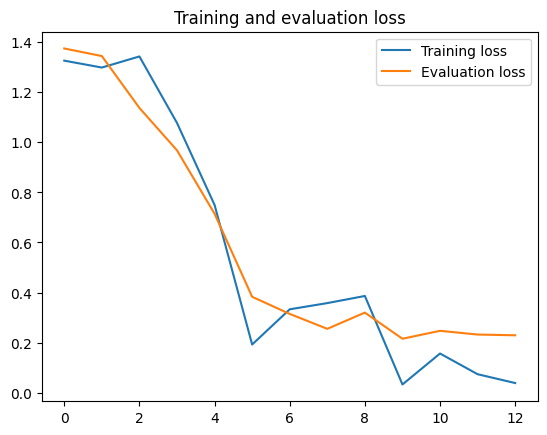

In [34]:
# Training and evaluation loss
train_loss = history['train_loss']
eval_loss = history['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

In [35]:
# Evaluate the model
result, model_outputs, wrong_predictions = model.eval_model(dev)
print(result)

  0%|          | 0/5 [00:00<?, ?it/s]

Running Evaluation:   0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


{'mcc': np.float64(0.909921293680513), 'eval_loss': 0.22979871236852237}


In [36]:
test = pd.read_csv("Sentiment-topic-test.tsv", sep="\t")
test.head()

,sentence id,text,sentiment,topic
0,0,It took eight years for Warner Brothers to rec...,negative,movie
1,1,All the New York University students love this...,positive,restaurant
2,2,This Italian place is really trendy but they h...,negative,restaurant
3,3,"In conclusion, my review of this book would be...",positive,book
4,4,The story of this movie is focused on Carl Bra...,neutral,movie


In [37]:
predicted, probabilities = model.predict(test.text.to_list())
test["predicted_topic"] = predicted
test.head()

0it [00:00, ?it/s]

Predicting:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:2260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


,sentence id,text,sentiment,topic,predicted_topic
0,0,It took eight years for Warner Brothers to rec...,negative,movie,1
1,1,All the New York University students love this...,positive,restaurant,0
2,2,This Italian place is really trendy but they h...,negative,restaurant,0
3,3,"In conclusion, my review of this book would be...",positive,book,0
4,4,The story of this movie is focused on Carl Bra...,neutral,movie,1


In [38]:
reverse_map = {v: k for k, v in label_map.items()}
test["predicted_topic_name"] = test["predicted_topic"].map(reverse_map)
test.head()

,sentence id,text,sentiment,topic,predicted_topic,predicted_topic_name
0,0,It took eight years for Warner Brothers to rec...,negative,movie,1,dvd
1,1,All the New York University students love this...,positive,restaurant,0,books
2,2,This Italian place is really trendy but they h...,negative,restaurant,0,books
3,3,"In conclusion, my review of this book would be...",positive,book,0,books
4,4,The story of this movie is focused on Carl Bra...,neutral,movie,1,dvd


In [39]:
print(classification_report(dev["labels"], model_outputs.argmax(axis=1)))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       646
           1       0.92      0.94      0.93       559
           2       0.95      0.93      0.94       795
           3       0.96      0.90      0.93       768

    accuracy                           0.93      2768
   macro avg       0.93      0.93      0.93      2768
weighted avg       0.93      0.93      0.93      2768



In [40]:
test.to_csv("topic_predictions.csv", index=False)